# Topic 5: Decision Trees

This notebook organizes the full Decision Tree practice from the original Jupyter file.

It covers:

- Titanic dataset loading and preprocessing
- Unrestricted Decision Tree
- `max_depth = 3, 5, 10`
- Overfitting curve
- Feature importance
- Manual Gini calculation
- Manual Information Gain for `sex`
- `model.tree_` internals
- `compute_node_depths()`
- Generalized Information Gain for any feature
- Manual Entropy calculation
- Pre-pruning
- Post-pruning using `ccp_alpha`
- Final comparison and conclusion

## 1. Imports

We import the libraries needed for data loading, modeling, plotting, and evaluation.

In [1]:
import seaborn as sns
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

## 2. Load Titanic Dataset

We use the Titanic dataset from seaborn. The target column is `survived`.

In [2]:
df = sns.load_dataset('titanic')

## 3. View First Five Rows

This gives a quick look at the dataset before cleaning.

In [3]:
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 4. Check Missing Values

Decision Trees in sklearn cannot directly handle missing values, so we check missing values before modeling.

In [4]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 5. Fill Missing Age Values

The `age` column has missing values. We fill them with the median age.

In [5]:
df['age'] = df['age'].fillna(df['age'].median())

## 6. Verify Missing Values Again

Now we check whether the `age` column has been cleaned.

In [6]:
df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 7. Encode Sex Column

The `sex` column is categorical, so we convert it into numbers.

- male = 1
- female = 0

In [7]:
df['sex'] = df['sex'].replace({'male': 1, 'female': 0})

## 8. View Cleaned Data

Now we view the data after encoding the `sex` column.

In [8]:
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 9. Select Features and Target

Features used:

- `sex`
- `pclass`
- `age`
- `sibsp`
- `parch`

Target:

- `survived`

In [9]:
x = df.loc[:, ['sex', 'pclass', 'age', 'sibsp', 'parch']]
y = df['survived']

## 10. Train-Test Split

We split the data into training and testing sets. Training data is used to build the model, and testing data checks performance on unseen data.

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    train_size=0.8,
    random_state=42
)

## 11. Unrestricted Decision Tree

This tree has no restrictions such as `max_depth`, `min_samples_split`, or `min_samples_leaf`.

An unrestricted tree can grow deep and overfit the training data.

In [11]:
model = DecisionTreeClassifier(random_state=42)

model.fit(x_train, y_train)

train_predict = model.predict(x_train)
test_predict = model.predict(x_test)

## 12. Unrestricted Tree Accuracy

We calculate train and test accuracy. A large gap between train and test accuracy indicates overfitting.

In [12]:
train_acc = accuracy_score(y_train, train_predict)
test_acc = accuracy_score(y_test, test_predict)

print("Unrestricted Tree")
print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

Unrestricted Tree
Train Accuracy: 0.9171348314606742
Test Accuracy : 0.7597765363128491


## 13. Decision Tree with `max_depth = 3`

A smaller depth creates a simpler tree and helps reduce overfitting.

In [13]:
model1 = DecisionTreeClassifier(max_depth=3, random_state=42)

model1.fit(x_train, y_train)

train_predict1 = model1.predict(x_train)
test_predict1 = model1.predict(x_test)

train_acc1 = accuracy_score(y_train, train_predict1)
test_acc1 = accuracy_score(y_test, test_predict1)

print("max_depth = 3")
print("Train Accuracy:", train_acc1)
print("Test Accuracy :", test_acc1)

max_depth = 3
Train Accuracy: 0.8286516853932584
Test Accuracy : 0.7877094972067039


## 14. Decision Tree with `max_depth = 5`

This tree is deeper than `max_depth=3` and may give a better balance between underfitting and overfitting.

In [14]:
model2 = DecisionTreeClassifier(max_depth=5, random_state=42)

model2.fit(x_train, y_train)

train_predict2 = model2.predict(x_train)
test_predict2 = model2.predict(x_test)

train_acc2 = accuracy_score(y_train, train_predict2)
test_acc2 = accuracy_score(y_test, test_predict2)

print("max_depth = 5")
print("Train Accuracy:", train_acc2)
print("Test Accuracy :", test_acc2)

max_depth = 5
Train Accuracy: 0.8398876404494382
Test Accuracy : 0.8100558659217877


## 15. Decision Tree with `max_depth = 10`

This tree is more complex and has higher overfitting risk.

In [15]:
model3 = DecisionTreeClassifier(max_depth=10, random_state=42)

model3.fit(x_train, y_train)

train_predict3 = model3.predict(x_train)
test_predict3 = model3.predict(x_test)

train_acc3 = accuracy_score(y_train, train_predict3)
test_acc3 = accuracy_score(y_test, test_predict3)

print("max_depth = 10")
print("Train Accuracy:", train_acc3)
print("Test Accuracy :", test_acc3)

max_depth = 10
Train Accuracy: 0.8862359550561798
Test Accuracy : 0.7653631284916201


## 16. Compare `max_depth = 3, 5, 10`

This table compares the train and test accuracy for different depths.

In [16]:
depth_results = pd.DataFrame({
    "Model": ["max_depth=3", "max_depth=5", "max_depth=10"],
    "Train Accuracy": [train_acc1, train_acc2, train_acc3],
    "Test Accuracy": [test_acc1, test_acc2, test_acc3]
})

depth_results

,Model,Train Accuracy,Test Accuracy
0,max_depth=3,0.828652,0.787709
1,max_depth=5,0.839888,0.810056
2,max_depth=10,0.886236,0.765363


## 17. Plot Trees for `max_depth = 3, 5, 10`

We visualize the three trees side by side.

Important correction: use `plot_tree(model, ax=axes[i])`. Do not assign `axes[i] = plot_tree(...)`.

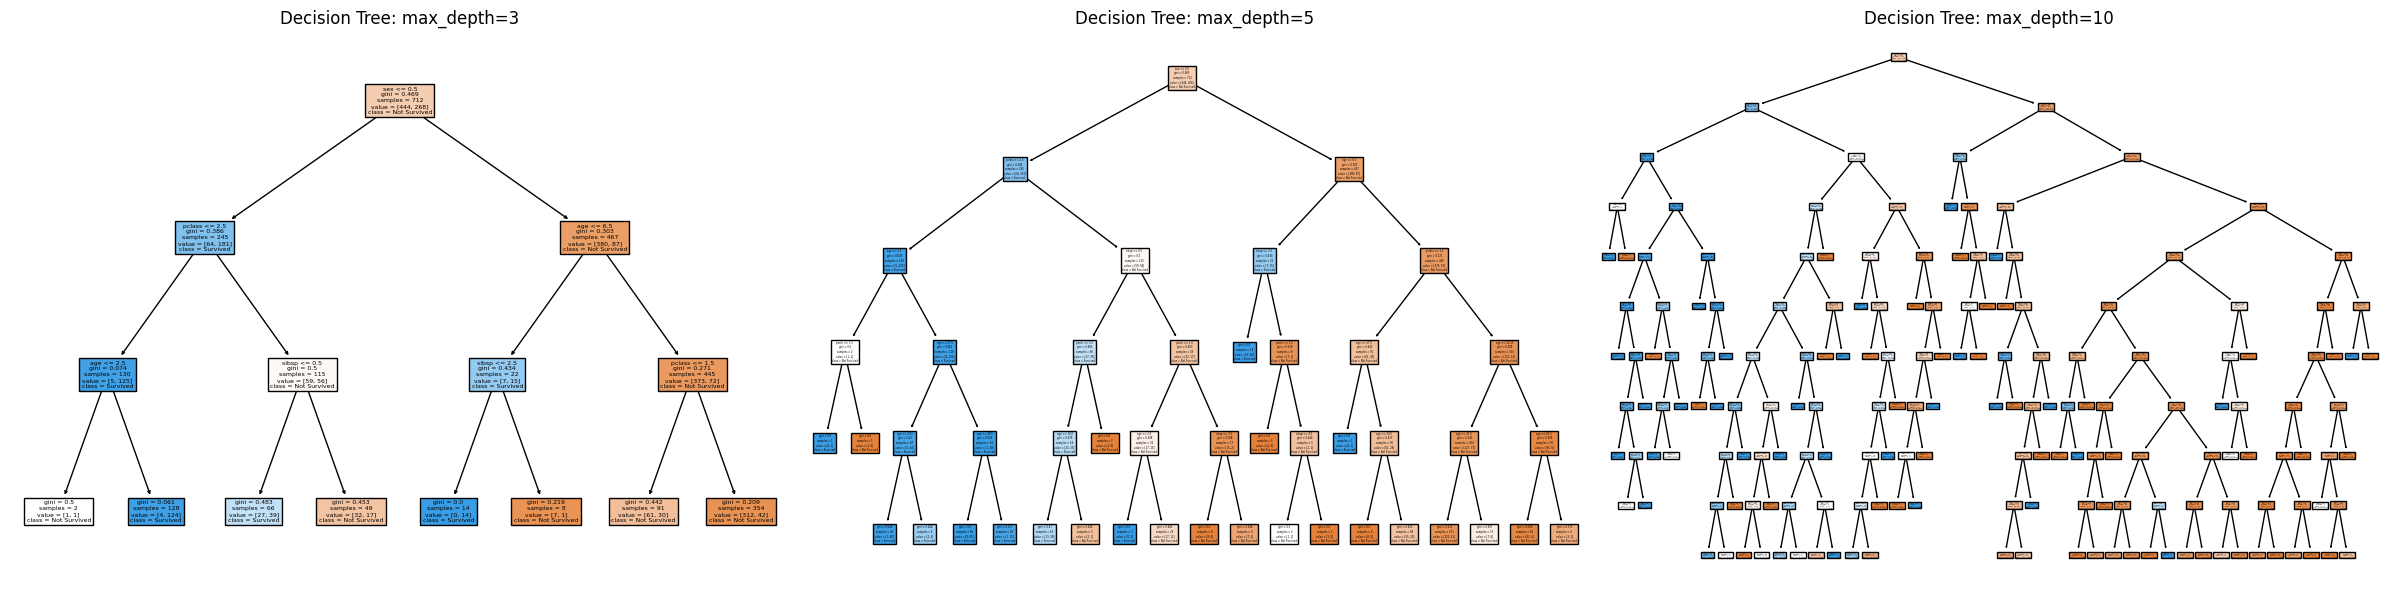

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

plot_tree(
    model1,
    ax=axes[0],
    filled=True,
    feature_names=x_train.columns,
    class_names=["Not Survived", "Survived"]
)
axes[0].set_title("Decision Tree: max_depth=3")

plot_tree(
    model2,
    ax=axes[1],
    filled=True,
    feature_names=x_train.columns,
    class_names=["Not Survived", "Survived"]
)
axes[1].set_title("Decision Tree: max_depth=5")

plot_tree(
    model3,
    ax=axes[2],
    filled=True,
    feature_names=x_train.columns,
    class_names=["Not Survived", "Survived"]
)
axes[2].set_title("Decision Tree: max_depth=10")

plt.tight_layout()
plt.show()

## 18. Overfit Curve

We train trees with depths from 1 to 14 and compare train vs test accuracy.

If train accuracy keeps increasing while test accuracy stops improving or drops, the model is overfitting.

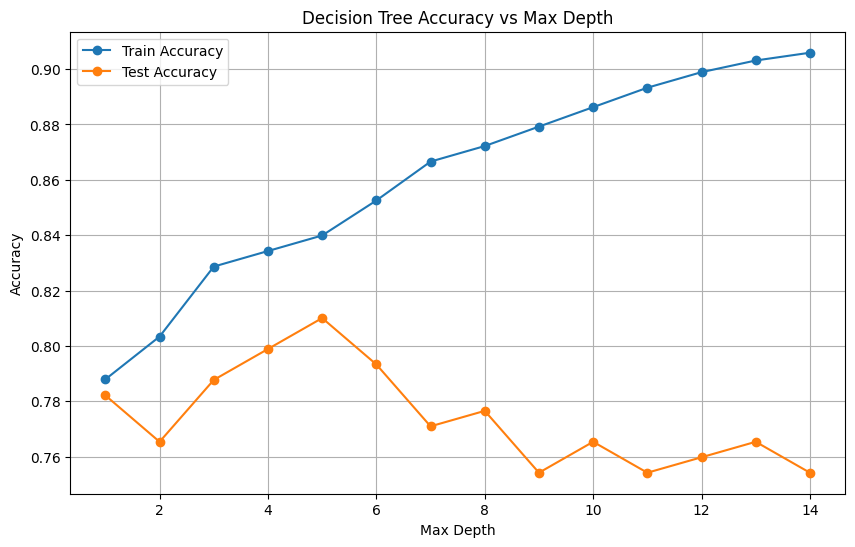

In [18]:
train_scores = []
test_scores = []
depths = range(1, 15)

for i in depths:
    depth_model = DecisionTreeClassifier(max_depth=i, random_state=42)
    depth_model.fit(x_train, y_train)

    train_predict = depth_model.predict(x_train)
    test_predict = depth_model.predict(x_test)

    train_acc = accuracy_score(y_train, train_predict)
    test_acc = accuracy_score(y_test, test_predict)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores, marker='o', label='Test Accuracy')

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.legend()
plt.grid(True)
plt.show()

## 19. Best `max_depth`

The best depth is the one with the highest test accuracy.

In [19]:
best_depth_index = np.argmax(test_scores)
best_depth = list(depths)[best_depth_index]

print("Best max_depth:", best_depth)
print("Best Test Accuracy:", test_scores[best_depth_index])

Best max_depth: 5
Best Test Accuracy: 0.8100558659217877


## 20. Feature Importance

Feature importance shows which variables helped the tree reduce impurity the most.

In [20]:
model2.feature_importances_

array([0.57141845, 0.19766467, 0.12904549, 0.06928589, 0.0325855 ])

## 21. Feature Importance DataFrame

The raw array is converted into a readable DataFrame.

In [21]:
feature_importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model2.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
0,sex,0.571418
1,pclass,0.197665
2,age,0.129045
3,sibsp,0.069286
4,parch,0.032586


## 22. Plot Feature Importance

The highest bar shows the most important feature.

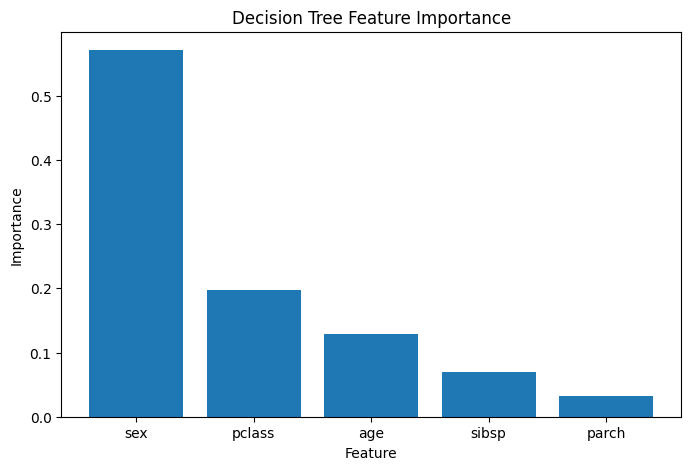

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.show()

## 23. View Feature Data

This matches the feature inspection from the original notebook.

In [23]:
x.head(5)

,sex,pclass,age,sibsp,parch
0,1,3,22.0,1,0
1,0,1,38.0,1,0
2,0,3,26.0,0,0
3,0,1,35.0,1,0
4,1,3,35.0,0,0


## 24. View Target Data

This matches the target inspection from the original notebook.

In [24]:
y_train.head(5)

331    0
733    0
382    0
704    0
813    0
Name: survived, dtype: int64

## 25. Manual Gini Calculation

Gini impurity measures how mixed the classes are.

Formula:

`Gini = 1 - p_survived² - p_not_survived²`

In [25]:
total_train = y_train.count()

filter_survived = (y_train == 1)

total_train_survived = y_train[filter_survived].count()
total_train_not_survived = y_train[~filter_survived].count()

prob_survived = total_train_survived / total_train
prob_not_survived = 1 - prob_survived

gini = 1 - (prob_survived ** 2) - (prob_not_survived ** 2)

print("Total train samples:", total_train)
print("Survived count:", total_train_survived)
print("Not survived count:", total_train_not_survived)
print("Probability survived:", prob_survived)
print("Probability not survived:", prob_not_survived)
print("Manual Gini:", round(gini, 4))

Total train samples: 712
Survived count: 268
Not survived count: 444
Probability survived: 0.37640449438202245
Probability not survived: 0.6235955056179776
Manual Gini: 0.4694


## 26. Verify Manual Gini with sklearn

The root node impurity is stored in `model.tree_.impurity[0]`.

In [26]:
internal_value = round(model.tree_.impurity[0], 4)

print("Manual Gini:", round(gini, 4))
print("sklearn Root Gini:", internal_value)

Manual Gini: 0.4694
sklearn Root Gini: 0.4694


## 27. Manual Information Gain for `sex`

Information Gain measures impurity reduction after a split.

Formula:

`Information Gain = Parent Gini - Weighted Child Gini`

Here we manually calculate Information Gain for the `sex` feature.

In [27]:
filter_male = x_train['sex'] == 1

males = y_train[filter_male]
females = y_train[~filter_male]

male_survived = males[males == 1].count()
female_survived = females[females == 1].count()

male_survived_prob = male_survived / males.count()
female_survived_prob = female_survived / females.count()

gini_male_survived = 1 - (male_survived_prob ** 2) - ((1 - male_survived_prob) ** 2)
gini_female_survived = 1 - (female_survived_prob ** 2) - ((1 - female_survived_prob) ** 2)

Information_gain_sex = gini - (
    ((males.count() / y_train.count()) * gini_male_survived)
    + ((females.count() / y_train.count()) * gini_female_survived)
)

print("Male Gini:", gini_male_survived)
print("Female Gini:", gini_female_survived)
print("Information Gain for sex:", Information_gain_sex)

Male Gini: 0.3031789773899647
Female Gini: 0.38597251145356104
Information Gain for sex: 0.13777997649438184


## 28. Gini Function From Scratch

Now we create a reusable function to calculate Gini impurity for any target column.

In [28]:
def gini_from_scratch(labels):
    probabilities = labels.value_counts(normalize=True)
    return 1 - sum(probabilities ** 2)

print("Gini from function:", gini_from_scratch(y_train))
print("Manual Gini:", gini)

Gini from function: 0.469448301982073
Manual Gini: 0.4694483019820728


## 29. `model.tree_` Root Node Internals

The `tree_` object stores the internal structure of the trained Decision Tree.

Here we inspect the root node, its children, impurity values, sample counts, and class counts.

In [29]:
tree = model.tree_

root_gini = tree.impurity[0]
root_feature = tree.feature[0]
root_samples = tree.n_node_samples[0]

left_child = tree.children_left[0]
right_child = tree.children_right[0]

print("Root Gini:", root_gini)
print("Root split feature index:", root_feature)
print("Root split feature name:", x_train.columns[root_feature])
print("Root samples:", root_samples)
print("Left child node:", left_child, "| Right child node:", right_child)

left_gini = tree.impurity[left_child]
right_gini = tree.impurity[right_child]
left_samples = tree.n_node_samples[left_child]
right_samples = tree.n_node_samples[right_child]

print()
print("Left child Gini:", left_gini, "| Samples:", left_samples)
print("Right child Gini:", right_gini, "| Samples:", right_samples)

print()
print("Root value counts:", tree.value[0])
print("Left child value counts:", tree.value[left_child])
print("Right child value counts:", tree.value[right_child])

information_gain_tree = root_gini - (
    (left_samples / root_samples) * left_gini
    + (right_samples / root_samples) * right_gini
)

print()
print("Information Gain from sklearn tree internals:", information_gain_tree)
print("Manual Information Gain for sex:", Information_gain_sex)


Root Gini: 0.469448301982073
Root split feature index: 0
Root split feature name: sex
Root samples: 712
Left child node: 1 | Right child node: 118

Left child Gini: 0.38597251145356104 | Samples: 245
Right child Gini: 0.3031789773899647 | Samples: 467

Root value counts: [[444. 268.]]
Left child value counts: [[ 64. 181.]]
Right child value counts: [[380.  87.]]

Information Gain from sklearn tree internals: 0.137779976494382
Manual Information Gain for sex: 0.13777997649438184


## 30. More `model.tree_` Internals

These arrays show the full structure of the tree.

- `feature`: feature index used at each node
- `threshold`: split threshold at each node
- `impurity`: Gini impurity at each node
- `children_left`: left child node index
- `children_right`: right child node index
- `n_node_samples`: samples at each node
- `value`: class counts at each node

In [30]:
print("Features used at each node:")
print(tree.feature)

print()
print("Thresholds at each node:")
print(tree.threshold)

print()
print("Impurity at each node:")
print(tree.impurity)

print()
print("Left child nodes:")
print(tree.children_left)

print()
print("Right child nodes:")
print(tree.children_right)

print()
print("Samples at each node:")
print(tree.n_node_samples)

print()
print("Class counts at each node:")
print(tree.value)


Features used at each node:
[ 0  1  2  4 -2 -2  2  2  2 -2  3  1 -2  4 -2 -2 -2  1 -2  4  3 -2 -2 -2
  2 -2  2  1 -2 -2 -2  3  4  2  2  2  2  2  2  4  2 -2 -2 -2  4 -2 -2 -2
 -2  4  2  2 -2  2  2  4 -2 -2 -2  2 -2  2 -2 -2 -2 -2  2 -2  2  4  2 -2
 -2  2 -2 -2 -2  2 -2 -2 -2  4  2 -2  2 -2  2  2  3  2  2  2 -2 -2  4  3
 -2 -2 -2  2 -2  4 -2 -2 -2 -2 -2  3 -2  3  2  2  2 -2 -2 -2 -2 -2  2  3
 -2  2 -2  2 -2 -2  1  2 -2  2 -2  2  4 -2 -2  2  2  4  2  2  3 -2 -2 -2
  2  2  3 -2 -2  2  2  2 -2 -2 -2  3  2  4 -2 -2 -2  2 -2 -2  2  2  3  2
 -2  2 -2 -2 -2 -2  2 -2  3  4  2  2  2 -2 -2 -2  2 -2  2 -2 -2  2 -2 -2
 -2 -2 -2 -2  2  2  2  3  3 -2 -2 -2  2  2  4  1 -2 -2 -2 -2  2  2  2  3
  1 -2  2 -2 -2  2 -2 -2  1 -2  2  2  3  2 -2 -2 -2 -2  3  4  2  3  2 -2
 -2 -2  3  2 -2 -2  2 -2 -2 -2 -2  1 -2 -2  2  1  4 -2 -2  4  3  3  2 -2
 -2 -2 -2 -2  2  1 -2 -2  2 -2  1 -2 -2  3  1 -2  3 -2 -2 -2  2  2  2  3
  1  2  2 -2 -2 -2  2 -2  2 -2 -2 -2  3  1 -2  2 -2  4 -2 -2 -2 -2  2 -2
 -2]

Thresholds at eac

## 30b. Understanding the `-2` Leaf Marker

Looking at the `feature` array above, some values are `-2` instead of a real
feature index (0-4). This is sklearn's placeholder meaning: **this node is a
leaf — no split happens here, so there is no feature to record.**

Every node in `model.tree_.feature` is either:
- A real feature index (0-4) → this node splits using that feature
- `-2` → this node is a leaf, the end of a branch, a final prediction point

This lets us count leaves directly, and distinguish leaf nodes from internal
split nodes anywhere in the tree.

In [31]:
leaf_mask = tree.feature == -2
num_leaves = leaf_mask.sum()
num_internal_nodes = tree.node_count - num_leaves

print("Total nodes:", tree.node_count)
print("Leaf nodes (-2 in feature array):", num_leaves)
print("Internal split nodes:", num_internal_nodes)

Total nodes: 313
Leaf nodes (-2 in feature array): 157
Internal split nodes: 156


## 31. Compute Node Depths

`compute_node_depths()` returns the depth of every node in the tree.

The root node has depth 0.

In [32]:
depths_array = tree.compute_node_depths()

print(depths_array)
print("Depth of node 118:", depths_array[118] if len(depths_array) > 118 else "Node 118 not available")

[ 1  2  3  4  5  5  4  5  6  7  7  8  9  9 10 10  8  6  7  7  8  9  9  8
  5  6  6  7  8  8  7  3  4  5  6  7  8  9 10 11 12 13 13 12 11 12 12 10
  9  8  9 10 11 11 12 13 14 14 13 12 13 13 14 14 10  9  7  8  8  9 10 11
 11 10 11 11  9  6  7  7  5  4  5  6  6  7  7  8  9 10 11 12 13 13 12 13
 14 14 13 11 12 12 13 13 10  9  8  5  6  6  7  8  9 10 10  9  8  7  2  3
  4  4  5  5  6  6  3  4  5  5  6  6  7  8  8  7  8  9 10 11 12 13 13 12
 11 12 13 14 14 13 14 15 16 16 15 14 15 16 17 17 16 15 16 16 12 13 14 15
 16 16 17 17 15 14 13 14 14 15 16 17 18 19 19 18 17 18 18 19 19 16 17 17
 15 10  9  8  4  5  6  7  8  9  9  8  7  8  9 10 11 11 10  9  8  9 10 11
 12 13 13 14 14 12 13 13 11 12 12 13 14 15 16 16 15 14 13 14 15 16 17 18
 18 17 16 17 18 18 17 18 18 15 14 10 11 11  9 10 11 12 12 11 12 13 14 15
 15 14 13 12 10 11 12 12 11 12 12 13 13  6  7  8  8  9  9  7  5  6  7  8
  9 10 11 12 12 11 10 11 11 12 12  9  8  9 10 10 11 11 12 12  9  7  6  7
  7]
Depth of node 118: 2


## 32. Complete Tree Summary DataFrame

This combines important tree internals into one readable table.

In [33]:
tree_summary = pd.DataFrame({
    "Node": np.arange(tree.node_count),
    "Feature Index": tree.feature,
    "Feature Name": [x_train.columns[i] if i >= 0 else "Leaf" for i in tree.feature],
    "Threshold": tree.threshold,
    "Gini": tree.impurity,
    "Samples": tree.n_node_samples,
    "Left Child": tree.children_left,
    "Right Child": tree.children_right,
    "Depth": depths_array
})

tree_summary.head(20)

,Node,Feature Index,Feature Name,Threshold,Gini,Samples,Left Child,Right Child,Depth
0,0,0,sex,0.5,0.469448,712,1,118,1
1,1,1,pclass,2.5,0.385973,245,2,31,2
2,2,2,age,2.5,0.073964,130,3,6,3
3,3,4,parch,1.5,0.500000,2,4,5,4
4,4,-2,Leaf,-2.0,0.000000,1,-1,-1,5
5,5,-2,Leaf,-2.0,0.000000,1,-1,-1,5
6,6,2,age,27.5,0.060547,128,7,24,4
7,7,2,age,24.5,0.119511,47,8,17,5
8,8,2,age,23.5,0.047591,41,9,10,6
9,9,-2,Leaf,-2.0,0.000000,29,-1,-1,7


## 33. Generalized Information Gain Using Tree Internals

This function calculates Information Gain for any feature at the first node where that feature is used in the trained tree.

This matches the generalized Information Gain work from the original notebook.

In [34]:
def info_gain_for_feature(feature_index):
    nodes = np.where(model.tree_.feature == feature_index)[0]
    
    if len(nodes) == 0:
        print(f"Feature {feature_index} is never used to split.")
        return None
    
    n = nodes[0]
    
    parent_gini = model.tree_.impurity[n]
    parent_samples = model.tree_.n_node_samples[n]
    
    left = model.tree_.children_left[n]
    right = model.tree_.children_right[n]
    
    left_gini = model.tree_.impurity[left]
    right_gini = model.tree_.impurity[right]
    left_samples = model.tree_.n_node_samples[left]
    right_samples = model.tree_.n_node_samples[right]
    
    gain = parent_gini - (
        (left_samples / parent_samples) * left_gini
        + (right_samples / parent_samples) * right_gini
    )
    
    print(f"Feature {feature_index} first split at node {n}, Information Gain: {gain}")
    return gain

feature_names = ['sex', 'pclass', 'age', 'sibsp', 'parch']

for i, name in enumerate(feature_names):
    print()
    print(f"--- {name} (index {i}) ---")
    info_gain_for_feature(i)



--- sex (index 0) ---
Feature 0 first split at node 0, Information Gain: 0.137779976494382

--- pclass (index 1) ---
Feature 1 first split at node 1, Information Gain: 0.11219188214498138

--- age (index 2) ---
Feature 2 first split at node 2, Information Gain: 0.006656804733727845

--- sibsp (index 3) ---
Feature 3 first split at node 10, Information Gain: 0.009920634920634885

--- parch (index 4) ---
Feature 4 first split at node 3, Information Gain: 0.5


## 34. Generalized Information Gain From Data

This is another reusable version that calculates Information Gain for any feature directly from the data.

For continuous features like `age`, this version treats every unique value as a category, so the tree-internal version is better for exact sklearn split verification. Still, this function is useful to understand the concept.

In [35]:
def information_gain_for_feature(data, feature, target):
    parent_gini = gini_from_scratch(data[target])
    total_samples = len(data)
    weighted_child_gini = 0
    
    for value in data[feature].unique():
        subset = data[data[feature] == value]
        weight = len(subset) / total_samples
        subset_gini = gini_from_scratch(subset[target])
        weighted_child_gini += weight * subset_gini
    
    return parent_gini - weighted_child_gini

train_df = x_train.copy()
train_df['survived'] = y_train

information_gain_results = []

for feature in x_train.columns:
    ig = information_gain_for_feature(train_df, feature, 'survived')
    information_gain_results.append({
        'Feature': feature,
        'Information Gain': ig
    })

information_gain_df = pd.DataFrame(information_gain_results).sort_values(
    by='Information Gain',
    ascending=False
)

information_gain_df

,Feature,Information Gain
0,sex,0.137780
2,age,0.069416
1,pclass,0.049718
4,parch,0.016587
3,sibsp,0.016308


## 35. Verify Root Feature Selected by sklearn

The Decision Tree selects the feature that gives the best impurity reduction at the root node.

In [36]:
root_feature_index = model.tree_.feature[0]
root_feature_name = x_train.columns[root_feature_index]

print("Root Feature Index:", root_feature_index)
print("Root Feature Name:", root_feature_name)

Root Feature Index: 0
Root Feature Name: sex


## 36. Manual Entropy Calculation

Entropy is another impurity measure.

Formula:

`Entropy = -p_survived log2(p_survived) - p_not_survived log2(p_not_survived)`

In [37]:
entropy = (
    prob_survived * math.log2(prob_survived)
    + prob_not_survived * math.log2(prob_not_survived)
) * -1

print("Manual Entropy:", entropy)

Manual Entropy: 0.9554629988004848


## 37. Entropy Function From Scratch

This function calculates Entropy for any label column.

In [38]:
def entropy_from_scratch(labels):
    probabilities = labels.value_counts(normalize=True)
    entropy_value = 0
    
    for p in probabilities:
        if p > 0:
            entropy_value += -p * math.log2(p)
    
    return entropy_value

print("Entropy from function:", entropy_from_scratch(y_train))
print("Manual Entropy:", entropy)

Entropy from function: 0.9554629988004849
Manual Entropy: 0.9554629988004848


## 38. Gini vs Entropy Summary

Both Gini and Entropy measure impurity.

Gini:

- Formula: `1 - sum(p²)`
- Default in sklearn
- Faster to calculate

Entropy:

- Formula: `-sum(p log2 p)`
- Based on information theory
- Used with `criterion='entropy'`

## 39. Pre-Pruning

Pre-pruning stops the tree early before it becomes too complex.

Here we use:

- `max_depth=5`
- `min_samples_split=20`
- `min_samples_leaf=5`

In [39]:
model4 = DecisionTreeClassifier(
    min_samples_leaf=5,
    min_samples_split=20,
    max_depth=5,
    random_state=42
)

model4.fit(x_train, y_train)

pred = model4.predict(x_test)
train_pred = model4.predict(x_train)

train_acc_pre = accuracy_score(y_train, train_pred)
test_acc_pre = accuracy_score(y_test, pred)

print("Pre-Pruned Tree")
print("Train Accuracy:", train_acc_pre)
print("Test Accuracy :", test_acc_pre)

Pre-Pruned Tree
Train Accuracy: 0.8342696629213483
Test Accuracy : 0.8044692737430168


## 40. Post-Pruning with `ccp_alpha`

Post-pruning first grows the tree and then removes weak branches.

`ccp_alpha` controls pruning strength:

- Small alpha = less pruning
- Large alpha = more pruning

In [40]:
path = model.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 4.25604358e-06 7.80274657e-06
 2.12802179e-05 2.86690015e-05 3.12109863e-05 6.68806849e-05
 1.00160056e-04 1.02145046e-04 1.08706996e-04 1.17041199e-04
 1.49812734e-04 1.84801892e-04 2.00642055e-04 2.15504429e-04
 2.34082397e-04 2.80898876e-04 3.33995615e-04 3.38059158e-04
 3.54670298e-04 3.56696986e-04 3.70247974e-04 3.74531835e-04
 3.74531835e-04 3.90137328e-04 4.20078100e-04 4.21348315e-04
 4.21348315e-04 4.57987298e-04 4.68164794e-04 4.68164794e-04
 5.03071818e-04 5.57339040e-04 5.81286966e-04 6.38406537e-04
 6.60938533e-04 7.07158011e-04 7.35687533e-04 8.82825040e-04
 9.24769963e-04 9.91407799e-04 9.94850187e-04 1.04095124e-03
 1.05337079e-03 1.05793083e-03 1.11315963e-03 1.22893258e-03
 1.24794330e-03 1.27565833e-03 1.30897840e-03 1.30996111e-03
 1.42712800e-03 1.46483151e-03 1.49731579e-03 1.52803787e-03
 1.58005618e-03 1.74035173e-03 1.81544478e-03 2.02295072e-03
 2.10674157e-03 2.34082397e-03 2.35172300e-03 2.49173423e-03
 2.65820640e-03 3.131488

## 41. Train One Model for Each Alpha

We train a Decision Tree for every `ccp_alpha` and store train/test accuracy.

In [41]:
alpha_train_scores = []
alpha_test_scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(x_train, y_train)
    
    train_pred = clf.predict(x_train)
    test_pred = clf.predict(x_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    alpha_train_scores.append(train_acc)
    alpha_test_scores.append(test_acc)

print(alpha_train_scores)
print(alpha_test_scores)

[0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9171348314606742, 0.9157303370786517, 0.9157303370786517, 0.9157303370786517, 0.9157303370786517, 0.9157303370786517, 0.9157303370786517, 0.9157303370786517, 0.9143258426966292, 0.9143258426966292, 0.9143258426966292, 0.9143258426966292, 0.9143258426966292, 0.9129213483146067, 0.9115168539325843, 0.9101123595505618, 0.9087078651685393, 0.9058988764044944, 0.8974719101123596, 0.8960674157303371, 0.8946629213483146, 0.8932584269662921, 0.8932584269662921, 0.8918539325842697, 0.8904494382022472, 0.8890449438202247,

## 42. Accuracy vs `ccp_alpha` Index

The actual `ccp_alpha` values can be very small and unevenly spaced.

Because of that, plotting accuracy directly against the alpha values can make the graph harder to read.

So here we use the **index position of each alpha** on the x-axis.

This makes the graph cleaner while still helping us select the best alpha.


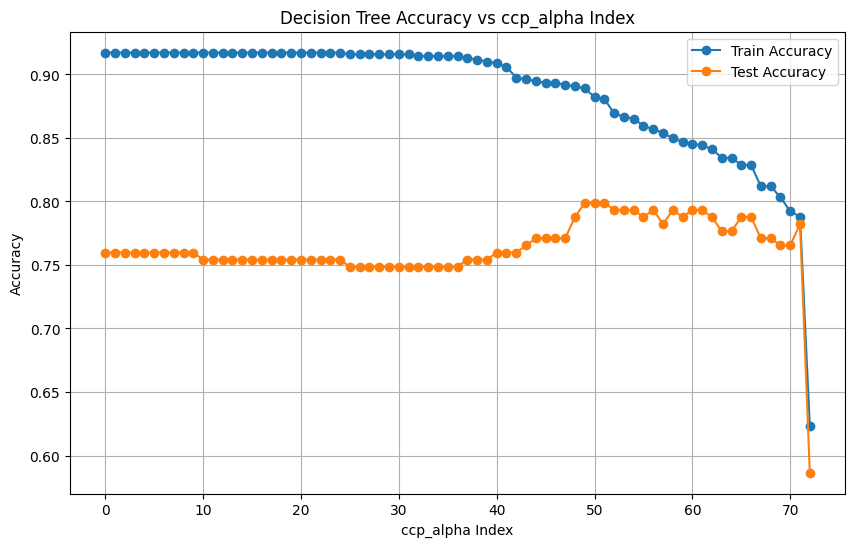

In [42]:
alpha_index = range(len(ccp_alphas))

plt.figure(figsize=(10, 6))

plt.plot(alpha_index, alpha_train_scores, marker='o', label='Train Accuracy')
plt.plot(alpha_index, alpha_test_scores, marker='o', label='Test Accuracy')

plt.xlabel('ccp_alpha Index')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs ccp_alpha Index')
plt.legend()
plt.grid(True)
plt.show()


## 43. Best Alpha Selection

The alpha-selection rule used here:

Choose the `ccp_alpha` value with the highest test accuracy.

In [43]:
best_index = alpha_test_scores.index(max(alpha_test_scores))
best_alpha = ccp_alphas[best_index]

print("Best index:", best_index)
print("Best alpha:", best_alpha)
print("Best test accuracy:", alpha_test_scores[best_index])

Best index: 49
Best alpha: 0.0012756583340591725
Best test accuracy: 0.7988826815642458


## 44. Compare Combined, Pre-Pruned, and Post-Pruned Models

This section preserves the comparison from the original notebook:

- `max_depth=5` with `ccp_alpha`
- `max_depth=5` only
- `ccp_alpha` only

In [44]:
combo_depth_alpha_model = DecisionTreeClassifier(
    max_depth=5,
    ccp_alpha=best_alpha,
    random_state=42
)
combo_depth_alpha_model.fit(x_train, y_train)

combo_train_pred = combo_depth_alpha_model.predict(x_train)
combo_test_pred = combo_depth_alpha_model.predict(x_test)

print("max_depth=5 + ccp_alpha")
print(accuracy_score(y_train, combo_train_pred), accuracy_score(y_test, combo_test_pred))

combo_depth_model = DecisionTreeClassifier(max_depth=5, random_state=42)
combo_depth_model.fit(x_train, y_train)

combo_train_pred = combo_depth_model.predict(x_train)
combo_test_pred = combo_depth_model.predict(x_test)

print()
print("max_depth=5 only")
print(accuracy_score(y_train, combo_train_pred), accuracy_score(y_test, combo_test_pred))

combo_alpha_model = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
combo_alpha_model.fit(x_train, y_train)

combo_train_pred = combo_alpha_model.predict(x_train)
combo_test_pred = combo_alpha_model.predict(x_test)

print()
print("ccp_alpha only")
print(accuracy_score(y_train, combo_train_pred), accuracy_score(y_test, combo_test_pred))


max_depth=5 + ccp_alpha
0.8384831460674157 0.7988826815642458

max_depth=5 only
0.8398876404494382 0.8100558659217877

ccp_alpha only
0.8890449438202247 0.7988826815642458


## 45. Retrain Unrestricted Tree and `max_depth=5` Tree

This matches the final retraining step from the original notebook before visualization.

In [45]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

train_predict = model.predict(x_train)
predict = model.predict(x_test)

train_acc_unrestricted = accuracy_score(y_train, train_predict)
test_acc_unrestricted = accuracy_score(y_test, predict)

print("Unrestricted Tree")
print(train_acc_unrestricted, test_acc_unrestricted)

combo_model = DecisionTreeClassifier(max_depth=5, random_state=42)
combo_model.fit(x_train, y_train)

combo_train_pred = combo_model.predict(x_train)
combo_test_pred = combo_model.predict(x_test)

train_acc_depth5 = accuracy_score(y_train, combo_train_pred)
test_acc_depth5 = accuracy_score(y_test, combo_test_pred)

print("max_depth=5 Tree")
print(train_acc_depth5, test_acc_depth5)

Unrestricted Tree
0.9171348314606742 0.7597765363128491
max_depth=5 Tree
0.8398876404494382 0.8100558659217877


## 46. Final Model Comparison Table

This table compares the important models clearly.

In [46]:
final_comparison = pd.DataFrame({
    'Model': [
        'Unrestricted Tree',
        'max_depth = 5',
        'Pre-Pruned Tree',
        'Post-Pruned Tree using ccp_alpha',
        'max_depth=5 + ccp_alpha'
    ],
    
    'Train Accuracy': [
        train_acc_unrestricted,
        train_acc_depth5,
        model4.score(x_train, y_train),
        combo_alpha_model.score(x_train, y_train),
        combo_depth_alpha_model.score(x_train, y_train)
    ],
    
    'Test Accuracy': [
        test_acc_unrestricted,
        test_acc_depth5,
        model4.score(x_test, y_test),
        combo_alpha_model.score(x_test, y_test),
        combo_depth_alpha_model.score(x_test, y_test)
    ],
    
    'Conclusion': [
        'High train accuracy, overfitting risk',
        'Good balance between train and test',
        'Best practical choice for this dataset',
        'Tested, but not necessary as final model here',
        'No major improvement over pre-pruning here'
    ]
})

final_comparison

,Model,Train Accuracy,Test Accuracy,Conclusion
0,Unrestricted Tree,0.917135,0.759777,"High train accuracy, overfitting risk"
1,max_depth = 5,0.839888,0.810056,Good balance between train and test
2,Pre-Pruned Tree,0.834270,0.804469,Best practical choice for this dataset
3,Post-Pruned Tree using ccp_alpha,0.889045,0.798883,"Tested, but not necessary as final model here"
4,max_depth=5 + ccp_alpha,0.838483,0.798883,No major improvement over pre-pruning here


## 47. Pruned vs Unpruned Tree Visualization

We compare the unrestricted tree with the simpler `max_depth=5` tree.

For this dataset, the simpler pre-pruned tree is easier to interpret and gives a good test result.

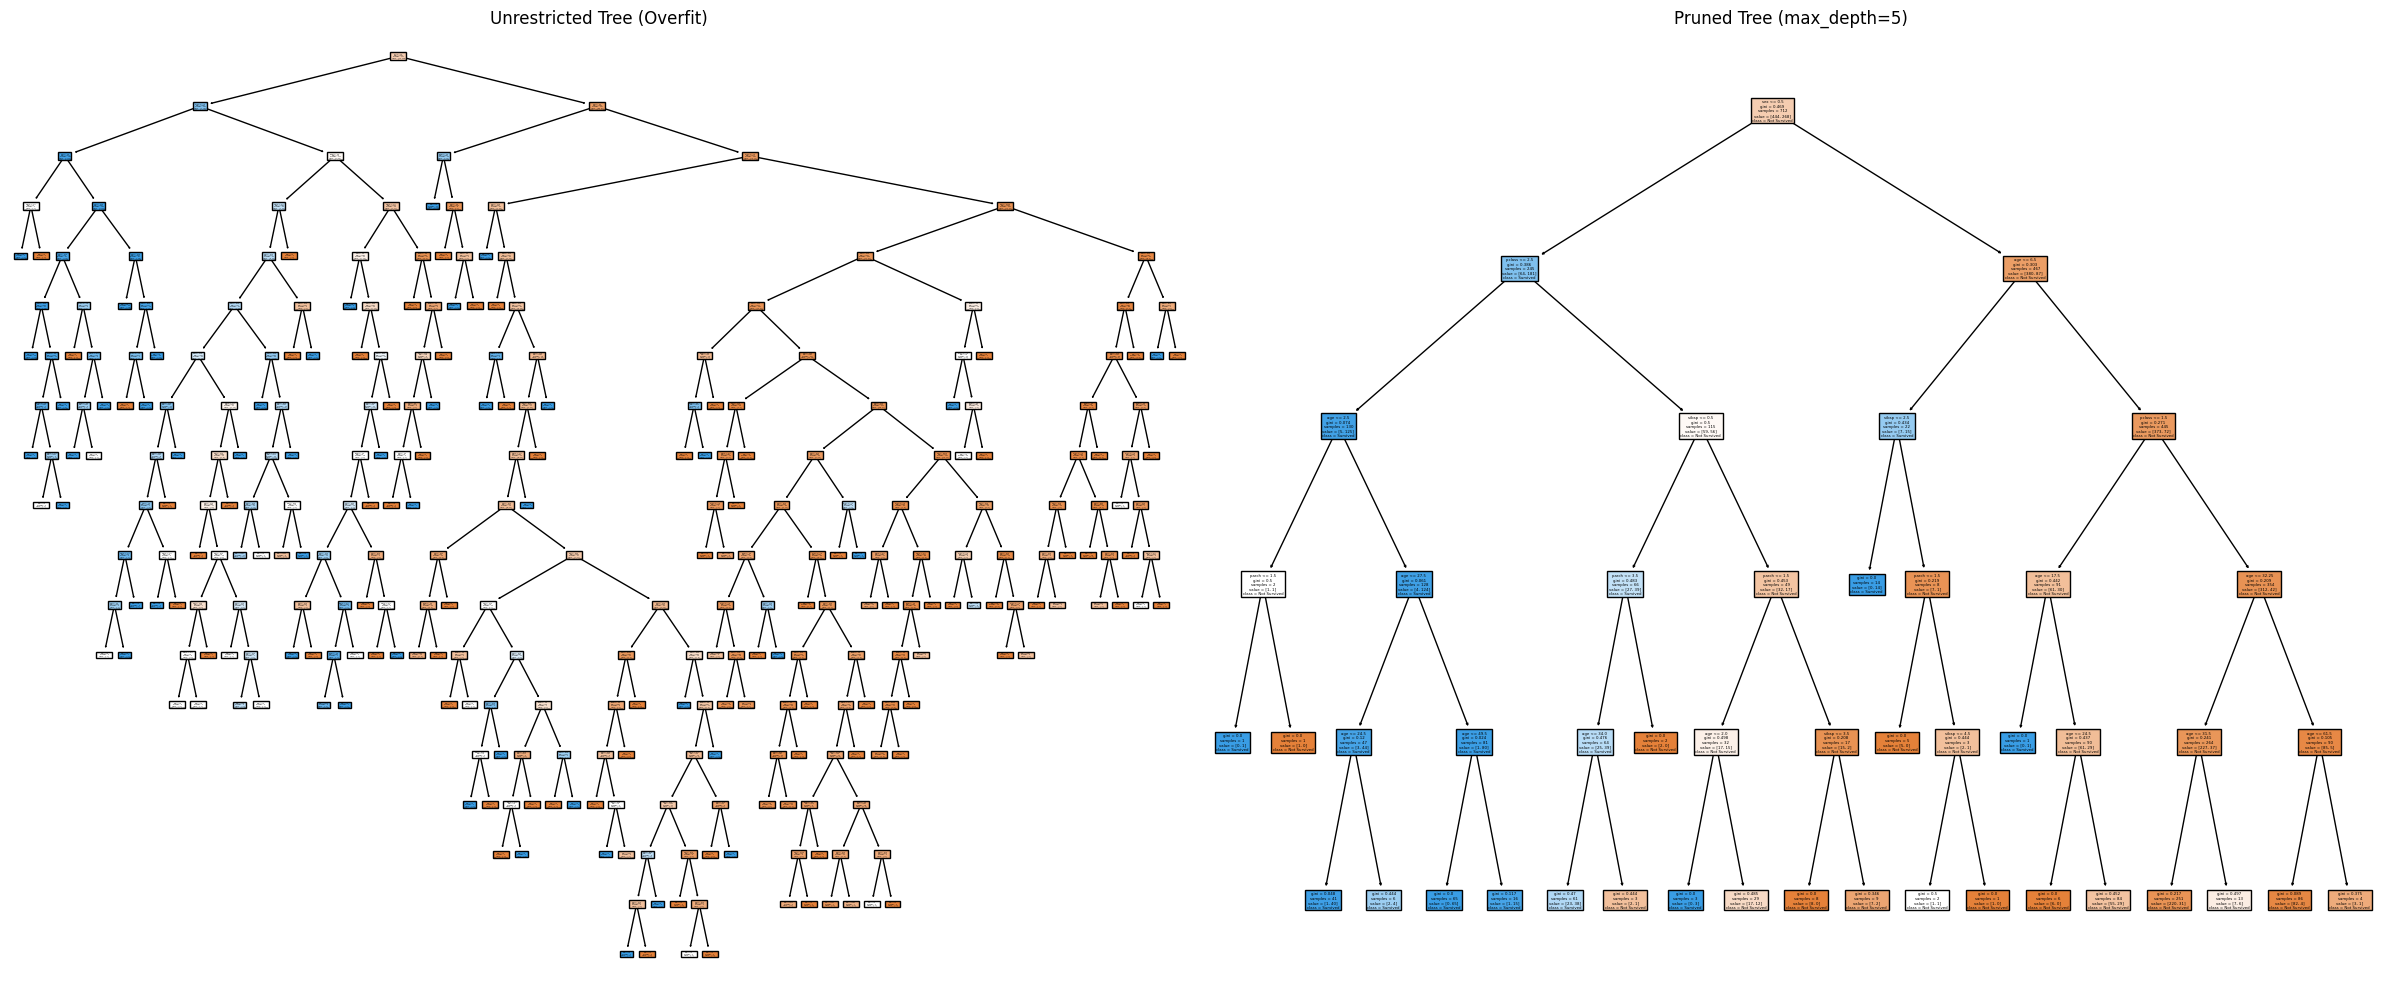

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

plot_tree(
    model,
    ax=axes[0],
    filled=True,
    feature_names=['sex', 'pclass', 'age', 'sibsp', 'parch'],
    class_names=["Not Survived", "Survived"]
)
axes[0].set_title("Unrestricted Tree (Overfit)")

plot_tree(
    combo_model,
    ax=axes[1],
    filled=True,
    feature_names=['sex', 'pclass', 'age', 'sibsp', 'parch'],
    class_names=["Not Survived", "Survived"]
)
axes[1].set_title("Pruned Tree (max_depth=5)")

plt.tight_layout()
plt.show()

## 48. Final Pruning Conclusion

For this Titanic dataset, post-pruning with `ccp_alpha` was tested, but it did not provide a major improvement over the simpler pre-pruned model.

The pre-pruned model is enough for this case because it controls overfitting directly using:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

So, for this notebook, the final practical conclusion is:

**Pre-pruning is more useful and easier to apply for this case.**

Post-pruning is still important to understand theoretically, but based on our results, it is not necessary as the final selected approach here.

## 49. Final Summary

In this notebook, we completed Decision Trees from theory to implementation.

Covered topics:

- Gini vs Entropy
- Information Gain
- Manual Gini calculation
- Manual Entropy calculation
- Manual Information Gain for `sex`
- Generalized Information Gain
- `model.tree_` internals
- Node depths using `compute_node_depths()`
- Feature importance
- Overfitting curve
- Pre-pruning
- Post-pruning using `ccp_alpha`
- Model comparison
- Pruned vs unpruned tree visualization

Final takeaway:

Decision Trees are easy to interpret but can overfit. In this Titanic case, pre-pruning using `max_depth`, `min_samples_split`, and `min_samples_leaf` is the most practical final approach.